In [69]:
from langgraph.graph import StateGraph ,START, END

from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [70]:
load_dotenv()

True

In [71]:
model = ChatGroq(model="llama-3.3-70b-versatile", temperature=0.7)

In [72]:
#create state

class BlogState(TypedDict):
    title: str
    outline: str
    content: str
    feedback: str


In [73]:
def create_outline(state: BlogState) -> BlogState:
    
    #fetch the tilte from the state and create an outline using the model
    
    title = state['title']
    
    # prompt the model to create an outline for the blog post based on the title
    
    prompt = f"generate a detailed outline for a blog post with the title: {title}"
    outline=model.invoke(prompt).content
    
    #update the state with the outline
    
    state['outline']=outline
    
    #return a new state with the outline added to it
    
    return state

In [74]:
def write_content(state: BlogState) -> BlogState:
    
    #fetch the title and outline from the state and write content for the blog post using the model
    title = state['title']
    outline = state['outline']
    
    # prompt the model to write content for the blog post based on the outline
    prompt = f"write a detailed blog on the title '{title}' based on the following outline: {outline}"
    
    content=model.invoke(prompt).content
    
    #update the state with the content
    state['content']=content
    
    #return a new state with the content added to it
    return state
    

In [75]:
def evaluate_content(state: BlogState) -> BlogState:
    
    #fetch the content from the state and evaluate it using the model
    
    content = state['content']
    
    # prompt the model to evaluate the content of the blog post and provide feedback
    prompt = f"evaluate the following blog content, give me ranking from 1-5 and provide feedback for improvement: {content}"
    
    feedback=model.invoke(prompt).content
    
    
    
    #update the state with the feedback
    state['feedback']=feedback
    
    #return a new state with the feedback added to it
    return state

In [76]:
graph=StateGraph(BlogState)

In [77]:
# adding node 

graph.add_node('create_outline',create_outline)
graph.add_node('write_content',write_content)
graph.add_node('evaluate_content',evaluate_content)


#define the edges between the nodes
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','write_content')
graph.add_edge('write_content','evaluate_content')
graph.add_edge('evaluate_content',END)




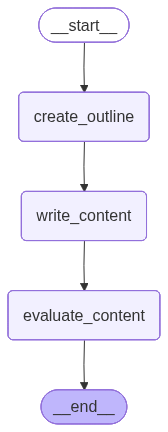

In [78]:
#compling the graph into a workflow

graph.compile()

In [79]:
workflow = graph.compile()

In [80]:
#defining the initial state with the title of the blog post

initial_state={'title':'How to use AI for collage students'}


#finally executing the workflow with the initial state

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'How to use AI for collage students', 'outline': 'Here is a detailed outline for a blog post on "How to Use AI for College Students":\n\n**I. Introduction**\n\n* Brief overview of AI and its increasing presence in education\n* Explanation of the purpose of the blog post: to explore the various ways college students can utilize AI to enhance their academic experience\n* Thesis statement: AI can be a powerful tool for college students, helping them to streamline their workflow, improve their productivity, and achieve their academic goals.\n\n**II. AI-Powered Study Tools**\n\n* Overview of AI-powered study tools, such as:\n\t+ Virtual flashcards (e.g. Quizlet, Anki)\n\t+ Intelligent tutoring systems (e.g. DreamBox, Knewton)\n\t+ AI-driven note-taking apps (e.g. Evernote, Simplenote)\n* Examples of how these tools can be used to:\n\t+ Enhance retention and recall of course material\n\t+ Provide personalized feedback and assessment\n\t+ Organize and review notes and study material

In [81]:
print(final_state['outline'])

Here is a detailed outline for a blog post on "How to Use AI for College Students":

**I. Introduction**

* Brief overview of AI and its increasing presence in education
* Explanation of the purpose of the blog post: to explore the various ways college students can utilize AI to enhance their academic experience
* Thesis statement: AI can be a powerful tool for college students, helping them to streamline their workflow, improve their productivity, and achieve their academic goals.

**II. AI-Powered Study Tools**

* Overview of AI-powered study tools, such as:
	+ Virtual flashcards (e.g. Quizlet, Anki)
	+ Intelligent tutoring systems (e.g. DreamBox, Knewton)
	+ AI-driven note-taking apps (e.g. Evernote, Simplenote)
* Examples of how these tools can be used to:
	+ Enhance retention and recall of course material
	+ Provide personalized feedback and assessment
	+ Organize and review notes and study materials

**III. AI-Assisted Research and Writing**

* Discussion of AI-powered research t

In [82]:
print(final_state['content'])

**How to Use AI for College Students: A Comprehensive Guide**

As we navigate the complexities of the 21st century, Artificial Intelligence (AI) has become an integral part of our daily lives. The education sector is no exception, with AI-powered tools and resources transforming the way we learn, study, and interact with academic materials. As a college student, you may be wondering how to harness the power of AI to enhance your academic experience. In this blog post, we'll explore the various ways AI can be used to streamline your workflow, improve your productivity, and achieve your academic goals.

**AI-Powered Study Tools**

One of the most significant advantages of AI in education is its ability to provide personalized learning experiences. AI-powered study tools, such as virtual flashcards, intelligent tutoring systems, and AI-driven note-taking apps, can help you enhance your retention and recall of course material. For example, Quizlet and Anki are popular virtual flashcard pla

In [84]:
print(final_state['feedback'])

I would rank this blog post a 4 out of 5. Here's why:

**Strengths:**

1. **Comprehensive guide**: The post provides a thorough overview of the various ways AI can be used by college students, covering study tools, research and writing, time management, and career development.
2. **Clear structure**: The post is well-organized, with each section focusing on a specific aspect of AI usage, making it easy to follow and understand.
3. **Practical examples**: The post includes many concrete examples of AI-powered tools and resources, which helps to illustrate the concepts and make them more relatable.
4. **Ethical considerations**: The post highlights the importance of using AI-powered tools responsibly and ethically, which is a crucial aspect of AI adoption in education.

**Weaknesses:**

1. **Length**: The post is quite long, which may deter some readers from reading it in its entirety. Consider breaking it up into smaller, more manageable sections or creating a series of posts on the top

In [83]:
#printing the feedback provided by the model for the content of the blog post
print(type(final_state))

print(final_state)

print('keys:', list(final_state.keys()) if isinstance(final_state, dict) else None)
if isinstance(final_state, dict):
    print('feedback:', final_state.get('feedback'))
else:
    print('feedback (attr):', getattr(final_state, 'feedback', None))

<class 'dict'>
{'title': 'How to use AI for collage students', 'outline': 'Here is a detailed outline for a blog post on "How to Use AI for College Students":\n\n**I. Introduction**\n\n* Brief overview of AI and its increasing presence in education\n* Explanation of the purpose of the blog post: to explore the various ways college students can utilize AI to enhance their academic experience\n* Thesis statement: AI can be a powerful tool for college students, helping them to streamline their workflow, improve their productivity, and achieve their academic goals.\n\n**II. AI-Powered Study Tools**\n\n* Overview of AI-powered study tools, such as:\n\t+ Virtual flashcards (e.g. Quizlet, Anki)\n\t+ Intelligent tutoring systems (e.g. DreamBox, Knewton)\n\t+ AI-driven note-taking apps (e.g. Evernote, Simplenote)\n* Examples of how these tools can be used to:\n\t+ Enhance retention and recall of course material\n\t+ Provide personalized feedback and assessment\n\t+ Organize and review notes and